In [18]:
import pandas as pd

# Read data set
dir_name = "/media/user/Data/Timeline/Data_table/"

file2013 = pd.read_csv(dir_name+"Datatable_2013_shift48hver2.csv")
file2014 = pd.read_csv(dir_name+"Datatable_2014_shift48hver2.csv")
file2015 = pd.read_csv(dir_name+"Datatable_2015_shift48hver2.csv")
file2016 = pd.read_csv(dir_name+"Datatable_2016_shift48hver2.csv")
file2017 = pd.read_csv(dir_name+"Datatable_2017_shift48hver2.csv")
file2018 = pd.read_csv(dir_name+"Datatable_2018_shift48hver2.csv")
file2019 = pd.read_csv(dir_name+"Datatable_2019_shift48hver2.csv")

In [19]:
#Set latitude
#lon1, lon2= -360, 360 # no limitation
lon1, lon2= 60, 150 

#Dataset prepare for the anomaly detection
df1 = pd.concat([file2013,file2014,file2015,file2016],ignore_index=True) #training periodic change
df1 = df1[(df1['Lon'] >= lon1) & (df1['Lon'] <= lon2) & (df1['Count'] >= 6.2)].copy() #Yoshioka et al. 2020 => lon. 60-150deg.  
df1["MLat"] = abs(df1["MLat"])

df2 = pd.concat([file2017,file2018,file2019],ignore_index=True) #Valification
df2 = df2[(df2['Lon'] >= lon1) & (df2['Lon'] <= lon2) & (df2['Count'] >= 6.2)].copy()
df2["MLat"] = abs(df2["MLat"])
dfr_test = df2.copy()

df1.head()

,Time,DOY,Year,Lon,Lat,LT,Geocenter,Count,Elec,Prot,...,SYM-H_t-47h,Mag_t-47h,Xray_t-47h,Prot_t-47h,Elec_t-47h,SYM-H_t-48h,Mag_t-48h,Xray_t-48h,Prot_t-48h,Elec_t-48h
1,2013-11-19T01:49:42,323.076181,2013,126.5528,24.1007,10.5054,7528,8.0,15364.707983,1.773712,...,-9.00000,91.477934,0.000001,1.268244,3533.729628,-4.0,87.952978,0.000001,1.798870,3270.730971
2,2013-11-19T01:50:42,323.076875,2013,129.7712,25.0754,10.7367,7528,12.0,15383.108223,1.829588,...,-9.00000,90.873389,0.000001,1.240121,3516.903647,-4.0,89.693961,0.000001,1.823547,3304.993657
3,2013-11-19T01:51:42,323.077569,2013,133.0430,25.9680,10.9714,7528,11.0,15421.523660,1.931290,...,-9.69936,90.265882,0.000001,1.227287,3524.546751,-4.0,91.426008,0.000001,1.836476,3329.525945
4,2013-11-19T01:52:42,323.078264,2013,136.3666,26.7738,11.2097,7527,13.0,15459.994451,2.033140,...,-10.70016,89.705855,0.000001,1.214435,3532.200867,-4.0,92.145044,0.000001,1.849425,3354.093581
5,2013-11-19T01:53:42,323.078958,2013,139.7393,27.4883,11.4512,7526,11.0,15498.409889,2.134843,...,-11.00000,89.435410,0.000001,1.201601,3539.843971,-4.0,92.319456,0.000001,1.862354,3378.625868


In [20]:
import numpy as np
import pandas as pd

# Time ==> Datetime
df1['Time'] = pd.to_datetime(df1['Time'], errors='coerce', utc=True)
df1['Time'] = df1['Time'].dt.tz_convert('UTC').dt.tz_localize(None)

sdir = "/media/user/Data/Timeline/Data_table/"
pt = pd.read_csv(sdir+'peak_times.csv', parse_dates=['Time'], dayfirst=False)
pt['Time'] = pd.to_datetime(pt['Time'], errors='coerce', utc=True)
pt['Time'] = pt['Time'].dt.tz_convert('UTC').dt.tz_localize(None)

# drip NaT
pt = pt.dropna(subset=['Time']).drop_duplicates().sort_values('Time').reset_index(drop=True)

# --- create ±3 day windows
win = pd.DataFrame({
    'start': pt['Time'] - pd.Timedelta(days=3),
    'end'  : pt['Time'] + pd.Timedelta(days=3),
}).sort_values('start').reset_index(drop=True)

# --- marge overlaped preiods
merged = []
for s, e in zip(win['start'], win['end']):
    if not merged or s > merged[-1][1]:
        merged.append([s, e])
    else:
        merged[-1][1] = max(merged[-1][1], e)

if len(merged) == 0:
    df1['is_anomaly_window'] = 0
else:
    win_merged = pd.DataFrame(merged, columns=['start', 'end'])

    # Convert all values to datetime64[ns] before using searchsorted
    starts = win_merged['start'].to_numpy(dtype='datetime64[ns]')
    ends   = win_merged['end'].to_numpy(dtype='datetime64[ns]')
    t      = df1['Time'].to_numpy(dtype='datetime64[ns]')

    # Searchsorted assumes that the array is sorted in ascending order
    sort_idx = np.argsort(starts)
    starts = starts[sort_idx]
    ends   = ends[sort_idx]

    idx = np.searchsorted(starts, t, side='right') - 1
    in_range = (idx >= 0) & (t <= ends[idx])

    df1['is_anomaly_window'] = in_range.astype(int)

df1n = df1[df1['is_anomaly_window'] == 0] #Normal variation

df1a = df1[df1['is_anomaly_window'] == 1] #Anomaly data
dfr_train = df1a.drop(columns=['is_anomaly_window']).copy()

In [21]:
#Cyclical features were encoded using sine and cosine transformations.

import numpy as np

def add_doy_sincos(df):
    is_leap = ((df["Year"] % 4 == 0) & (df["Year"] % 100 != 0)) | (df["Year"] % 400 == 0)
    year_len = np.where(is_leap.to_numpy(), 366, 365).astype(float)
    doy = df["DOY"].to_numpy()

    # 1 <= DOY <= year_len 
    # doy = np.clip(doy, 1.0, year_len)

    theta = 2 * np.pi * (doy - 1.0) / year_len
    df["DOY_sin"] = np.sin(theta)
    df["DOY_cos"] = np.cos(theta)
    return df

def add_lt_sincos(df):
    # 0<=LT<24
    lt = np.mod(df["LT"].to_numpy(), 24.0)
    theta = 2 * np.pi * lt / 24.0
    df["LT_sin"] = np.sin(theta)
    df["LT_cos"] = np.cos(theta)
    return df

def add_mlon_sincos(df):
    # simulate the range of -180〜180
    # mlon = ((df["MLon"].to_numpy() + 180.0) % 360.0) - 180.0
    mlon = df["MLon"].to_numpy()
    theta = np.deg2rad(mlon)
    df["MLon_sin"] = np.sin(theta)
    df["MLon_cos"] = np.cos(theta)
    return df

for d in (df1n, df1a, df2):
    add_doy_sincos(d)
    add_lt_sincos(d)
    add_mlon_sincos(d)

In [22]:
from sklearn.preprocessing import StandardScaler
# Standarization target
features_to_scale = ["Year",  "MLat", "Geocenter"] 
features_target = ["Time", "DOY","Year", "MLat", "Geocenter","DOY_sin","DOY_cos","LT_sin","LT_cos",
               "MLon_sin","MLon_cos", "Count"]

#Training data
df_tra1 = df1n[features_target] #bedore Scale
# Standarization and fitting
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_tra1[features_to_scale])

# Create dataset after standarization
df_tra1_scaled = df_tra1.copy()
df_tra1_scaled[features_to_scale] = scaled_values
print(df_tra1_scaled.head())

#Training data2
df_tra2 = df1a[features_target] 
scaled_values = scaler.transform(df_tra2[features_to_scale]) #NG => fit_transform
df_tra2_scaled = df_tra2.copy()
df_tra2_scaled[features_to_scale] = scaled_values
print(df_tra2_scaled.head())

#Test data
df_tes1 = df2[features_target] 
scaled_values = scaler.transform(df_tes1[features_to_scale])
df_tes1_scaled = df_tes1.copy()
df_tes1_scaled[features_to_scale] = scaled_values
print(df_tes1_scaled.head())

                  Time         DOY      Year      MLat  Geocenter   DOY_sin  \
88 2013-11-23 05:07:08  327.213287 -2.420113 -0.057859   1.271508 -0.619168   
89 2013-11-23 05:08:08  327.213981 -2.420113 -0.129196   1.243778 -0.619158   
90 2013-11-23 05:09:08  327.214676 -2.420113 -0.207955   1.216048 -0.619149   
91 2013-11-23 05:10:08  327.215370 -2.420113 -0.293549   1.174454 -0.619140   
92 2013-11-23 05:11:08  327.216065 -2.420113 -0.383402   1.132859 -0.619130   

     DOY_cos    LT_sin    LT_cos  MLon_sin  MLon_cos  Count  
88  0.785259 -0.227867 -0.973692 -0.102669 -0.994716   10.0  
89  0.785266 -0.289282 -0.957244 -0.160048 -0.987109   13.0  
90  0.785274 -0.348817 -0.937191 -0.215927 -0.976409   27.0  
91  0.785281 -0.406210 -0.913780 -0.270098 -0.962833   15.0  
92  0.785288 -0.461253 -0.887269 -0.322412 -0.946599   15.0  
                 Time         DOY      Year      MLat  Geocenter   DOY_sin  \
1 2013-11-19 01:49:42  323.076181 -2.420113 -0.398196   1.340832 -0.673475 

In [23]:
from pycaret.regression import *
from pycaret.regression import get_config, pull
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit

#PyCaret setup
reg1 = setup(data=df_tra1_scaled, target='Count',ignore_features=["Time","DOY"],
             fold_strategy="timeseries",fold=5,data_split_shuffle=False,fold_shuffle=False,session_id=123)


,Description,Value
0,Session id,123
1,Target,Count
2,Target type,Regression
3,Original data shape,"(162977, 12)"
4,Transformed data shape,"(162977, 10)"
5,Transformed train set shape,"(114083, 10)"
6,Transformed test set shape,"(48894, 10)"
7,Ignore features,2
8,Numeric features,9
9,Preprocess,True


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.8233,12.7897,3.5763,0.0856,0.2530,0.2300
1,2.8295,12.3778,3.5182,0.0517,0.2576,0.2453
2,2.7078,11.5498,3.3985,0.0609,0.2492,0.2297
3,2.7325,11.7984,3.4349,0.0867,0.2526,0.2371
4,2.7373,11.7853,3.4330,0.0873,0.2501,0.2323
Mean,2.7661,12.0602,3.4722,0.0745,0.2525,0.2349
Std,0.0503,0.4555,0.0653,0.0151,0.0029,0.0058


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.8226,12.7659,3.5729,0.0873,0.2529,0.2304
1,2.8295,12.3760,3.5180,0.0518,0.2576,0.2453
2,2.7077,11.5491,3.3984,0.0610,0.2492,0.2297
3,2.7325,11.7983,3.4349,0.0868,0.2526,0.2371
4,2.7373,11.7853,3.4330,0.0873,0.2501,0.2323
Mean,2.7659,12.0549,3.4714,0.0748,0.2525,0.2350
Std,0.0501,0.4479,0.0642,0.0153,0.0029,0.0058


Fitting 5 folds for each of 10 candidates, totalling 50 fits


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Ridge Regression,3.6236,22.2053,4.7122,-0.2336,0.2993,0.2375


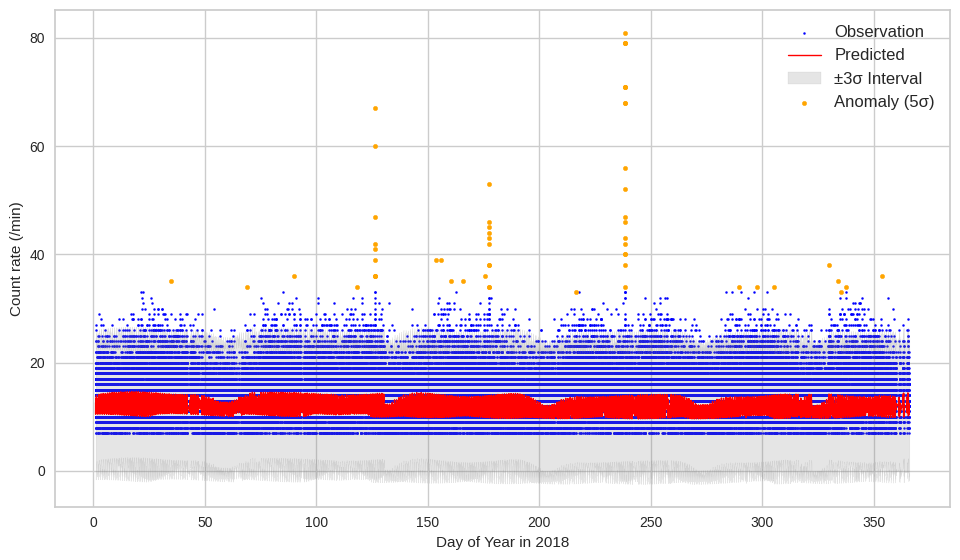

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from pycaret.regression import *

# モデル作成と予測
model = create_model("ridge")
model2 = tune_model(model,optimize="RMSE")
test_pred = predict_model(model2, data=df_tes1_scaled)


# only use the data of Year=2018
mask_year = df_tes1["Year"] == 2018
dfm_year = test_pred[mask_year].reset_index(drop=True)
df_tes1_year = df_tes1[mask_year].reset_index(drop=True)

# 実測値・予測値・横軸
y_true = dfm_year["Count"]
y_pred = dfm_year["prediction_label"]
time = df_tes1_year["DOY"]  # スケーリング前のDOYをそのまま使う

# 残差と標準偏差
residuals = y_true - y_pred
std_dev = np.std(residuals)

# 信頼区間（±3σ, ±5σ）
conf3 = 3
conf5 = 5
y_pred_lower = y_pred - conf3 * std_dev
y_pred_upper = y_pred + conf3 * std_dev
y_pred_lower2 = y_pred - conf5 * std_dev
y_pred_upper2 = y_pred + conf5 * std_dev

# プロット
plt.rcParams["font.size"] = 20
plt.figure(figsize=(10,6))
plt.scatter(time, y_true, label='Observation', color='blue', s=2)
plt.plot(time, y_pred, label='Predicted', color='red', linewidth=1)
plt.fill_between(time, y_pred_lower, y_pred_upper, color='gray', alpha=0.2, label='±3σ Interval')

# Anomaly over ±3σ interval
#mask_outlier_3sigma = y_true > y_pred + conf3 * std_dev
#plt.scatter(time[mask_outlier_3sigma], y_true[mask_outlier_3sigma],
            #label='Anomaly (3σ)', color='red', s=8)

# Anomaly over ±5σ interval
mask_outlier_5sigma = y_true > y_pred + conf5 * std_dev
plt.scatter(time[mask_outlier_5sigma], y_true[mask_outlier_5sigma],
            label='Anomaly (5σ)', color='orange', s=10)


plt.xlabel('Day of Year in 2018')
plt.ylabel('Count rate (/min)')
#plt.xlim([40,50])
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
#Save Residual data
model = create_model("ridge")
train_pred = predict_model(model, data=df_tra2_scaled)
residual1 = train_pred["Count"] - train_pred["prediction_label"]
#Replace counts
dfr_train["Count"]= residual1 
sdir = "/media/user/Data/Timeline/Data_table/"
dfr_train.to_csv(sdir + "residual_train_lon"+str(lon1)+"-"+str(lon2)+".csv", index=False) #2014 DOY>350

test_pred = predict_model(model, data=df_tes1_scaled)
residual2 = test_pred["Count"] - test_pred["prediction_label"]
#Replace counts
dfr_test["Count"]= residual2
dfr_test.to_csv(sdir + "residual_test_lon"+str(lon1)+"-"+str(lon2)+".csv", index=False) #2014 DOY>350

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.8233,12.7897,3.5763,0.0856,0.2530,0.2300
1,2.8295,12.3778,3.5182,0.0517,0.2576,0.2453
2,2.7078,11.5498,3.3985,0.0609,0.2492,0.2297
3,2.7325,11.7984,3.4349,0.0867,0.2526,0.2371
4,2.7373,11.7853,3.4330,0.0873,0.2501,0.2323
Mean,2.7661,12.0602,3.4722,0.0745,0.2525,0.2349
Std,0.0503,0.4555,0.0653,0.0151,0.0029,0.0058


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Ridge Regression,3.2077,25.8522,5.0845,0.0636,0.2813,0.2417


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Ridge Regression,3.6237,22.2059,4.7123,-0.2336,0.2993,0.2375


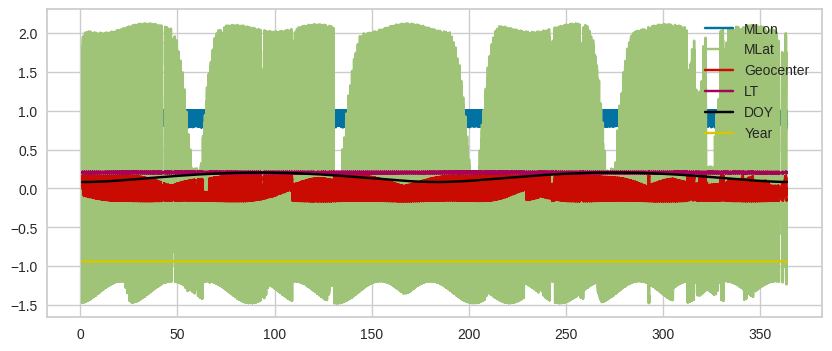

[-0.2558406   1.0752112  -0.11417351  0.20371386  0.08257211  0.19582258
 -0.21278581  0.549861    1.0052285 ]


In [25]:
import matplotlib.pyplot as plt
# Explanatory variables during the test period
test_features = df_tes1_scaled.drop(['Count','Time','DOY'], axis=1)

# Example: 2018/8
mask = (df_tes1["Time"] >= "2018-01-01") & (df_tes1["Time"] < "2018-12-31")
df_sub = df_tes1[mask].copy()
test_sub = test_features[mask].copy()
coefficients = model.coef_
contributions_sub = test_sub * coefficients

DOY_contrib = np.sqrt(contributions_sub['DOY_cos']**2+contributions_sub['DOY_sin']**2)
LT_contrib = np.sqrt(contributions_sub['LT_cos']**2+contributions_sub['LT_sin']**2)
Mlon_contrib = np.sqrt(contributions_sub['MLon_cos']**2+contributions_sub['MLon_sin']**2)

plt.plot(df_sub["DOY"], Mlon_contrib, label="MLon")
plt.plot(df_sub["DOY"], contributions_sub['MLat'], label="MLat")
plt.plot(df_sub["DOY"], contributions_sub['Geocenter'], label="Geocenter")
plt.plot(df_sub["DOY"], LT_contrib, label="LT")
plt.plot(df_sub["DOY"], DOY_contrib, label="DOY", color="black")
plt.plot(df_sub["DOY"], contributions_sub['Year'], label="Year")

plt.legend()
#plt.savefig("ParameterContribution_withSYMH"+str(year) + '-' + str(month) +".png")
plt.show()
print(coefficients)

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from pycaret.regression import *

# Model prediction and observation
model = create_model("ridge")
model2 = tune_model(model,optimize="RMSE")
test_pred = predict_model(model2, data=df_tes1_scaled)
#test_pred = predict_model(model, data=df_tes1_scaled)

# Only use the data of Year=2018
mask_year = df_tes1["Year"] == 2017
dfm_year = test_pred[mask_year].reset_index(drop=True)
df_tes1_year = df_tes1[mask_year].reset_index(drop=True)

y_true = dfm_year["Count"]
y_pred = dfm_year["prediction_label"]
time = df_tes1_year["DOY"]  # スケーリング前のDOYをそのまま使う

 #Residual and standard deviation
residuals = y_true - y_pred
std_dev = np.std(residuals)

# Confidence interval（±3σ, ±5σ）
conf3 = 3
conf5 = 5
y_pred_lower = y_pred - conf3 * std_dev
y_pred_upper = y_pred + conf3 * std_dev


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.8233,12.7897,3.5763,0.0856,0.2530,0.2300
1,2.8295,12.3778,3.5182,0.0517,0.2576,0.2453
2,2.7078,11.5498,3.3985,0.0609,0.2492,0.2297
3,2.7325,11.7984,3.4349,0.0867,0.2526,0.2371
4,2.7373,11.7853,3.4330,0.0873,0.2501,0.2323
Mean,2.7661,12.0602,3.4722,0.0745,0.2525,0.2349
Std,0.0503,0.4555,0.0653,0.0151,0.0029,0.0058


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.8226,12.7659,3.5729,0.0873,0.2529,0.2304
1,2.8295,12.3760,3.5180,0.0518,0.2576,0.2453
2,2.7077,11.5491,3.3984,0.0610,0.2492,0.2297
3,2.7325,11.7983,3.4349,0.0868,0.2526,0.2371
4,2.7373,11.7853,3.4330,0.0873,0.2501,0.2323
Mean,2.7659,12.0549,3.4714,0.0748,0.2525,0.2350
Std,0.0501,0.4479,0.0642,0.0153,0.0029,0.0058


Fitting 5 folds for each of 10 candidates, totalling 50 fits


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Ridge Regression,3.6236,22.2053,4.7122,-0.2336,0.2993,0.2375


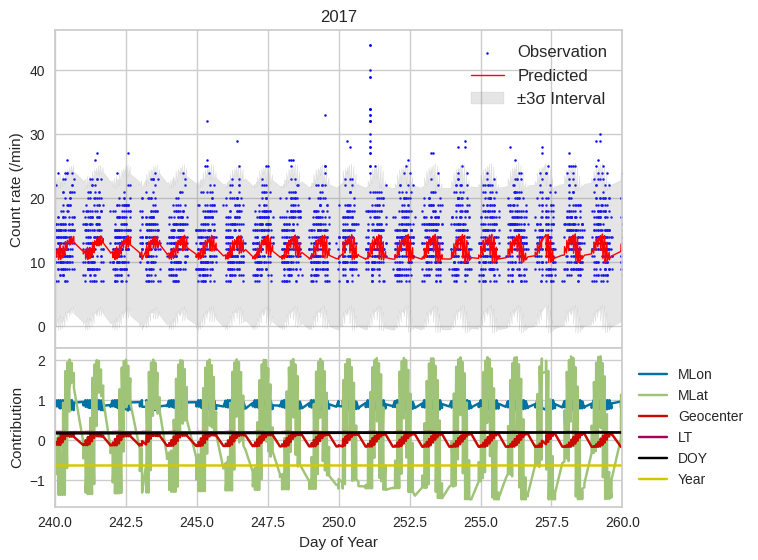

In [28]:
plt.rcParams["font.size"] = 20
fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(8, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1],"hspace": 0}
)

# Plot
ax1.scatter(time, y_true, label='Observation', color='blue', s=2)
ax1.plot(time, y_pred, label='Predicted', color='red', linewidth=1)
ax1.fill_between(time, y_pred_lower, y_pred_upper, color='gray', alpha=0.2, label='±3σ Interval')
ax1.legend(fontsize=12)

df_sub = df_tes1[mask_year].copy()
test_sub = test_features[mask_year].copy()
coefficients = model.coef_
contributions_sub = test_sub * coefficients

DOY_contrib = np.sqrt(contributions_sub['DOY_cos']**2+contributions_sub['DOY_sin']**2)
LT_contrib = np.sqrt(contributions_sub['LT_cos']**2+contributions_sub['LT_sin']**2)
Mlon_contrib = np.sqrt(contributions_sub['MLon_cos']**2+contributions_sub['MLon_sin']**2)

ax2.plot(df_sub["DOY"], Mlon_contrib, label="MLon")
ax2.plot(df_sub["DOY"], contributions_sub['MLat'], label="MLat")
ax2.plot(df_sub["DOY"], contributions_sub['Geocenter'], label="Geocenter")
ax2.plot(df_sub["DOY"], LT_contrib, label="LT")
ax2.plot(df_sub["DOY"], DOY_contrib, label="DOY", color="black")
ax2.plot(df_sub["DOY"], contributions_sub['Year'], label="Year")

ax2.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0
)

# Axis label
ax2.set_xlabel('Day of Year')
ax1.set_ylabel('Count rate (/min)')
ax2.set_ylabel('Contribution')
plt.xlim([240,260])
ax1.set_title("2017")
#plt.legend(fontsize=12)
#plt.subplots_adjust(right=0.78)
plt.tight_layout()
plt.savefig("Normal model 2017.jpg",dpi=400)
plt.show()